In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from deduplicate import remove_less_detailed_code

In [2]:
icd9 = pd.read_json('../data/icd9-cm-2015-code.json').T
icd9 = icd9.reset_index(names="Code")
icd9

,Code,code,title,exclude,sex,synonym,include,codeAlso,note,fourth-digit
0,00,00,"Procedures and interventions , Not Elsewhere C...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000,00.0,Therapeutic ultrasound,[diagnostic ultrasound (non-invasive) (88.71-8...,NaN,NaN,NaN,NaN,NaN,NaN
2,0001,00.01,Therapeutic ultrasound of vessels of head and ...,"[diagnostic ultrasound of: eye (95.13), diagno...",B,"[Anti-restenotic ultrasound, Intravascular non...",NaN,NaN,NaN,NaN
3,0002,00.02,Therapeutic ultrasound of heart,"[diagnostic ultrasound of heart (88.72), ultra...",B,"[Anti-restenotic ultrasound, Intravascular non...",NaN,NaN,NaN,NaN
4,0003,00.03,Therapeutic ultrasound of peripheral vascular ...,[diagnostic ultrasound of peripheral vascular ...,B,"[Anti-restenotic ultrasound, Intravascular non...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4641,9995,99.95,Stretching of foreskin,NaN,B,NaN,NaN,NaN,NaN,NaN
4642,9996,99.96,Collection of sperm for artificial insemination,NaN,M,NaN,NaN,NaN,NaN,NaN
4643,9997,99.97,Fitting of denture,NaN,B,NaN,NaN,NaN,NaN,NaN
4644,9998,99.98,Extraction of milk from lactating breast,NaN,F,NaN,NaN,NaN,NaN,NaN


In [3]:
with open('../data/index_icd9.json') as f:
    icd9_index = json.load(f)

def flatten_nodes(node, parent_terms=None):
    if parent_terms is None:
        parent_terms = []
        
    rows = []
    # Combine parent terms with the current node's term
    current_terms = parent_terms + [node.get('term', '')]
    full_term = " ".join(current_terms).strip()
    
    # Append the current node data
    rows.append({
        'term': full_term,
        'code': node.get('code', None)
    })
    
    # Recurse down into any children
    for child in node.get('children', []):
        rows.extend(flatten_nodes(child, current_terms))
        
    return rows

icd9_index_df = []
for item in icd9_index:
    icd9_index_df.extend(flatten_nodes(item))

icd9_index_df = pd.DataFrame(icd9_index_df)
icd9_index_df = icd9_index_df.dropna()
icd9_index_df['Code'] = icd9_index_df['code'].str.replace('.','')
icd9_index_df['Code'] = icd9_index_df['Code'].str.findall(r"\d+")
icd9_index_df

,term,code,Code
1,Abbe operation construction of vagina,70.61,[7061]
2,Abbe operation construction of vagina with gra...,70.63,[7063]
4,"Abciximab, infusion",99.20,[9920]
5,Abdominocentesis,54.91,[5491]
6,Abdominohysterectomy,68.49,[6849]
...,...,...,...
20704,Z-plasty epicanthus,08.59,[0859]
20705,"Z-plasty eyelid --see also Reconstruction, eyelid",08.70,[0870]
20706,Z-plasty hypopharynx,29.4,[294]
20707,Z-plasty skin (scar) (web contracture),86.84,[8684]


### if code is already exist in other code inclusion then remove

In [4]:
# Map from inclusion to icd9 for defining including icd9 code
# Prepare all name of icd9 from title, synonym, and index
title = icd9[["Code", "title"]].copy()
title = title.groupby("title", as_index=False).agg(list)
title['Code'] = title['Code'].apply(remove_less_detailed_code)
display(title.query("title == 'Other'"))
title = title[title['title'] != 'Other'].copy()
print("Remove title = 'Other'")
title

Removed: '512' (Reason: Less detailed version of '5122')
Removed: '148' (Reason: Less detailed version of '1481')
Removed: '992' (Reason: Less detailed version of '9929')
Removed: '663' (Reason: Less detailed version of '6639')
Removed: '136' (Reason: Less detailed version of '1369')
Removed: '823' (Reason: Less detailed version of '8239')
Removed: '673' (Reason: Less detailed version of '6739')
Removed: '135' (Reason: Less detailed version of '1359')
Removed: '363' (Reason: Less detailed version of '3639')
Removed: '935' (Reason: Less detailed version of '9359')
Removed: '75' (Reason: Less detailed version of '759')
Removed: '04' (Reason: Less detailed version of '049')
Removed: '37' (Reason: Less detailed version of '379')
Removed: '09' (Reason: Less detailed version of '099')
Removed: '31' (Reason: Less detailed version of '319')
Removed: '33' (Reason: Less detailed version of '339')
Removed: '20' (Reason: Less detailed version of '2099')
Removed: '27' (Reason: Less detailed version

,title,Code
2408,Other,"[0299, 0399, 0499, 0589, 0639, 0749, 0779, 085..."


Remove title = 'Other'


,title,Code
0,(Aorto)coronary bypass of four or more coronar...,[3614]
1,(Aorto)coronary bypass of one coronary artery,[3611]
2,(Aorto)coronary bypass of three coronary arteries,[3613]
3,(Aorto)coronary bypass of two coronary arteries,[3612]
4,(Laparoscopic) adjustment of size of adjustabl...,[4498]
...,...,...
4534,X-ray of urinary system,[877]
4535,X-ray study of eye,[9514]
4536,"X-ray, other and unspecified",[8839]
4537,Xerography of breast,[8736]


In [5]:
syn = icd9[["Code", "synonym"]].copy().explode("synonym").dropna()
syn = syn.rename(columns={"synonym": "title"})
print("Remove title = '(99.77)'")
syn = syn[syn['title'] != '(99.77)'].copy()
syn = syn.groupby(["title"], as_index=False).agg(list)
syn['Code'] = syn['Code'].apply(remove_less_detailed_code)

syn

Remove title = '(99.77)'
Removed: '176' (Reason: Less detailed version of '1761')
Removed: '684' (Reason: Less detailed version of '6849')


,title,Code
0,"""Cocked-hat"" procedure [skin flap and bone]",[8269]
1,14 C-Urea breath test,[8939]
2,Abbreviated history and evaluation,[8901]
3,Abdominoperineal pull-through,[4849]
4,Ablation (contact) (noncontact) by laser,[6021]
...,...,...
4037,percutaneous transluminal coronary angioplasty...,[3607]
4038,procedure on vessel bifurcation (00.44),[3607]
4039,stabilization device(s),[8483]
4040,transluminal coronary atherectomy (17.55),[3607]


In [6]:
index = icd9_index_df[["Code", "term"]].copy().rename(columns={"term": "title"})
index = index.groupby(["title"], as_index=False).agg(lambda x: x.sum())
index['Code'] = index['Code'].apply(set).apply(remove_less_detailed_code)
index

Removed: '783' (Reason: Less detailed version of '7839')


,title,Code
0,AESOP (Automated Endoscopic System for Optimal...,[174]
1,Abbe operation construction of vagina,[7061]
2,Abbe operation construction of vagina with gra...,[7063]
3,"Abciximab, infusion",[9920]
4,Abdominocentesis,[5491]
...,...,...
16363,through previously implanted catheter or reser...,[0102]
16364,transsphenoidal approach (complete) (total),[0765]
16365,transsphenoidal approach (complete) (total) pa...,[0762]
16366,von Kraske operation (proctectomy),[4864]


In [7]:
main = pd.concat([title, syn, index], ignore_index=True)
cleaning_patterns = {
    r'^\s*\[[\d\-]+\]\s*': ' ',                # Wipes bracketed prefixes e.g. [0-9]
    r'\s*\(\d+(?:\.\d+)?\)\s*': ' ',           # Wipes parenthetical codes e.g. (42.91)
    r'[()\[\]]': '',                           # Strips literal brackets and parentheses
    r':|"|\bNOS\b|\bNEC\b|--see also\b|--see category\b|--seecategory\b|--see categories\b|--see\b': '',
    r'\s+': ' '                                # Collapses multi-spaces down to a single space
}

# Apply all regex cleanups iteratively on the original "title" column
clean_titles = main["title"].copy()
for pattern, replacement in cleaning_patterns.items():
    clean_titles = clean_titles.str.replace(pattern, replacement, regex=True)

main["clean_title"] = clean_titles.str.strip()

main = main.groupby(['title','clean_title'], as_index = False).agg(lambda x: x.sum())
main['Code'] = main['Code'].apply(set).apply(remove_less_detailed_code)
main.drop_duplicates(subset=['clean_title'], keep='first', inplace=True)
main

Removed: '802' (Reason: Less detailed version of '8020')
Removed: '730' (Reason: Less detailed version of '7309')
Removed: '104' (Reason: Less detailed version of '1049')
Removed: '020' (Reason: Less detailed version of '0206')
Removed: '380' (Reason: Less detailed version of '3800')
Removed: '450' (Reason: Less detailed version of '4500')
Removed: '421' (Reason: Less detailed version of '4210')
Removed: '462' (Reason: Less detailed version of '4620')
Removed: '650' (Reason: Less detailed version of '6509')
Removed: '787' (Reason: Less detailed version of '7870')
Removed: '276' (Reason: Less detailed version of '2769')
Removed: '520' (Reason: Less detailed version of '5209')
Removed: '650' (Reason: Less detailed version of '6509')
Removed: '191' (Reason: Less detailed version of '1919')
Removed: '923' (Reason: Less detailed version of '9230')
Removed: '888' (Reason: Less detailed version of '8889')
Removed: '380' (Reason: Less detailed version of '3800')
Removed: '078' (Reason: Less de

,title,clean_title,Code
0,"""Cocked-hat"" procedure [skin flap and bone]",Cocked-hat procedure skin flap and bone,[8269]
1,(Aorto)coronary bypass of four or more coronar...,Aortocoronary bypass of four or more coronary ...,[3614]
2,(Aorto)coronary bypass of one coronary artery,Aortocoronary bypass of one coronary artery,[3611]
3,(Aorto)coronary bypass of three coronary arteries,Aortocoronary bypass of three coronary arteries,[3613]
4,(Aorto)coronary bypass of two coronary arteries,Aortocoronary bypass of two coronary arteries,[3612]
...,...,...,...
24660,transsphenoidal approach (complete) (total),transsphenoidal approach complete total,[0765]
24661,transsphenoidal approach (complete) (total) pa...,transsphenoidal approach complete total partial,[0762]
24662,vascular NOS,vascular,[3929]
24663,von Kraske operation (proctectomy),von Kraske operation proctectomy,[4864]


In [8]:
main['title'].nunique(), main['clean_title'].nunique()

(24557, 24557)

In [36]:
inc = icd9[["Code", "title", "include"]].copy().explode("include").dropna()
inc['clean_include'] = inc['include'].str.replace(r'[()\[\]]', '', regex=True)
inc["clean_include"] = inc["clean_include"].str.replace(':|NOS','', regex=True)
inc['clean_include'] = inc['clean_include'].str.replace(r'\s+', ' ', regex=True).str.strip()
inc

,Code,title,include,clean_include
15,0018,Infusion of immunosuppressive antibody therapy,during induction phase of solid organ transpla...,during induction phase of solid organ transpla...
15,0018,Infusion of immunosuppressive antibody therapy,monoclonal antibody therapy,monoclonal antibody therapy
15,0018,Infusion of immunosuppressive antibody therapy,polyclonal antibody therapy,polyclonal antibody therapy
53,0059,Intravascular pressure measurement of coronary...,fractional flow reserve (FFR),fractional flow reserve FFR
58,0063,Percutaneous insertion of carotid artery stent(s),"the use of any embolic protection device, dist...","the use of any embolic protection device, dist..."
...,...,...,...,...
4560,991,Injection or infusion of therapeutic or prophy...,injection or infusion given: intramuscularly a...,injection or infusion given intramuscularly ac...
4560,991,Injection or infusion of therapeutic or prophy...,injection or infusion given: intravenously act...,injection or infusion given intravenously acti...
4571,992,Injection or infusion of other therapeutic or ...,injection or infusion given: hypodermically ac...,injection or infusion given hypodermically act...
4571,992,Injection or infusion of other therapeutic or ...,injection or infusion given: intramuscularly a...,injection or infusion given intramuscularly ac...


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

choices = main["clean_title"].tolist()
queries = inc['clean_include'].tolist()

print(f"Calculating Cosine Similarity for {len(queries)} queries against {len(choices)} choices...")

vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3))

# 3. Fit the vectorizer on ALL text to build the vocabulary, then transform them
all_text = np.concatenate([choices, queries])
vectorizer.fit(all_text)

choices_matrix = vectorizer.transform(choices)
queries_matrix = vectorizer.transform(queries)

# 4. Calculate the Cosine Similarity instantly for all pairs
similarity_matrix = cosine_similarity(queries_matrix, choices_matrix)

results = []
top_k = 5

for query_idx in range(len(queries)):
    query_text = queries[query_idx]
    scores = similarity_matrix[query_idx]
    top5_indices = np.argsort(scores)[-top_k:][::-1]
    
    for rank, choice_idx in enumerate(top5_indices, start=1):
        matched_title = choices[choice_idx]
        score = scores[choice_idx] * 100
        
        results.append({
            "include": query_text,
            "rank": rank,
            "matched_title": matched_title,
            "score": score
        })

top5_df = pd.DataFrame(results)
top5_df

Calculating Cosine Similarity for 277 queries against 24557 choices...


,include,rank,matched_title,score
0,during induction phase of solid organ transpla...,1,"Transplant, transplantation dura",46.998784
1,during induction phase of solid organ transpla...,2,"Transplant, transplantation salivary duct opening",45.852700
2,during induction phase of solid organ transpla...,3,Transplantation of salivary duct opening,44.429920
3,during induction phase of solid organ transpla...,4,Transplantation of bone,43.778140
4,during induction phase of solid organ transpla...,5,"Transplant, transplantation intestine",42.132450
...,...,...,...,...
1380,injection or infusion given intravenously acti...,1,Introduction therapeutic substance acting loca...,59.915363
1381,injection or infusion given intravenously acti...,2,Intravenous injection or instillation,49.921766
1382,injection or infusion given intravenously acti...,3,Injection into hypodermically platelet inhibit...,47.770406
1383,injection or infusion given intravenously acti...,4,Injection into hypodermically antivenin,47.466097


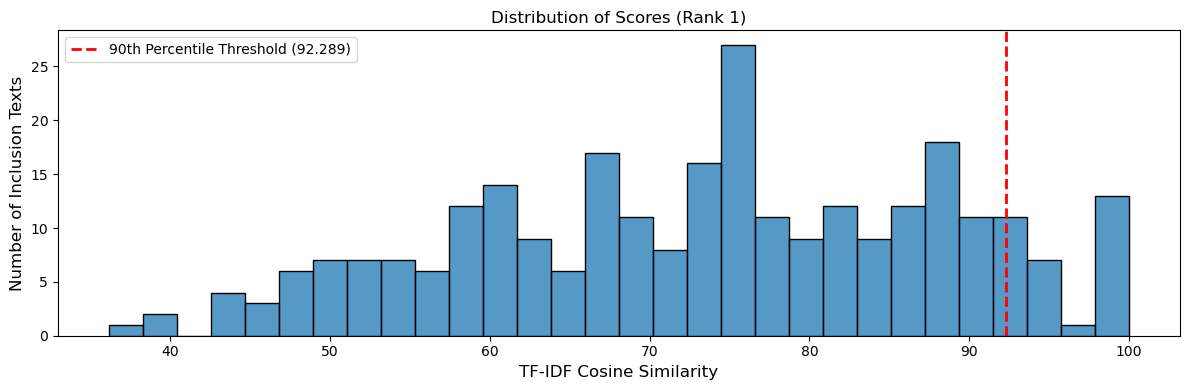

In [38]:
rank1_df = top5_df.query('rank == 1')
P = 90 # Increase for higher confidence, and vice versa.
threshold = np.percentile(rank1_df['score'], P)

fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(
    data=rank1_df, 
    x="score", 
    bins=30,
    ax=ax
)

ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'{P}th Percentile Threshold ({threshold:.3f})')

ax.set_title("Distribution of Scores (Rank 1)", fontsize=12)
ax.set_xlabel("TF-IDF Cosine Similarity", fontsize=12)
ax.set_ylabel("Number of Inclusion Texts", fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
cutoff_res = top5_df.query(f'score >= {threshold}')

mapped_count = len(cutoff_res['include'].unique())
total_count = len(queries)
print(f"Successfully Mapped: {mapped_count / total_count:.2%} ({mapped_count} out of {total_count} inclusions)")

cutoff_res = cutoff_res.merge(main, left_on='matched_title', right_on='clean_title', how='left')
cutoff_res = cutoff_res.drop(columns = ["clean_title"])
cutoff_res

Successfully Mapped: 9.39% (26 out of 277 inclusions)


,include,rank,matched_title,score,title,Code
0,operations on pineal gland,1,Operations on pineal gland,100.000000,Operations on pineal gland,[075]
1,operations on pineal gland,2,Other operations on pineal gland,92.839137,Other operations on pineal gland,[0759]
2,operations on pituitary gland,1,Operation pituitary gland,94.169243,Operation pituitary gland NEC,[0779]
3,operations on thymus,1,Other operations on thymus,92.475046,Other operations on thymus,[079]
4,Directional atherectomy,1,Directional atherectomy,100.000000,Directional atherectomy,"[1755, 1753, 1754]"
5,Excimer laser atherectomy,1,Excimer laser atherectomy,100.000000,Excimer laser atherectomy,"[1755, 1753, 1754]"
6,Rotational atherectomy,1,Rotational atherectomy,100.000000,Rotational atherectomy,"[1755, 1753, 1754]"
7,mastoidectomy,1,Mastoidectomy,100.000000,Mastoidectomy,[204]
8,mastoidectomy,1,Mastoidectomy,100.000000,Mastoidectomy,[204]
9,mastoidectomy,1,Mastoidectomy,100.000000,Mastoidectomy,[204]


In [41]:
inc_map = cutoff_res[["Code", "include"]]
print(f"Successfully Mapped: {len(inc_map['include'].unique()) / len(queries):.2%} ({len(inc_map['include'].unique())} out of {len(queries)} inclusions)")
inc_map

Successfully Mapped: 9.39% (26 out of 277 inclusions)


,Code,include
0,[075],operations on pineal gland
1,[0759],operations on pineal gland
2,[0779],operations on pituitary gland
3,[079],operations on thymus
4,"[1755, 1753, 1754]",Directional atherectomy
5,"[1755, 1753, 1754]",Excimer laser atherectomy
6,"[1755, 1753, 1754]",Rotational atherectomy
7,[204],mastoidectomy
8,[204],mastoidectomy
9,[204],mastoidectomy


In [ ]:
inc_map_df = inc.merge(inc_map, left_on='clean_include', right_on='include', how='left', suffixes=('', '_include'))
inc_map_df = inc_map_df.drop(columns = ["clean_include", "include_include"])
inc_map_df = inc_map_df.explode('Code_include')
inc_map_df = inc_map_df.query("Code != Code_include") # Exclude map include to self
inc_map_df = inc_map_df.drop_duplicates()
inc_map_df = inc_map_df.dropna()
inc_map_df = inc_map_df.groupby(['Code', 'title', 'include'], as_index=False).agg(list)
inc_map_df['Code_include'] = inc_map_df['Code_include'].apply(remove_less_detailed_code)
inc_map_df

Removed: '075' (Reason: Less detailed version of '0759')


,Code,title,include,Code_include
0,07,Operations on other endocrine glands,operations on: pineal gland,[0759]
1,07,Operations on other endocrine glands,operations on: pituitary gland,[0779]
2,07,Operations on other endocrine glands,operations on: thymus,[079]
3,1756,Atherectomy of other non-coronary vessel(s),Directional atherectomy,"[1755, 1753, 1754]"
4,1756,Atherectomy of other non-coronary vessel(s),Excimer laser atherectomy,"[1755, 1753, 1754]"
5,1756,Atherectomy of other non-coronary vessel(s),Rotational atherectomy,"[1755, 1753, 1754]"
6,2096,Implantation or replacement of cochlear prosth...,mastoidectomy,[204]
7,2097,Implantation or replacement of cochlear prosth...,mastoidectomy,[204]
8,2098,Implantation or replacement of cochlear prosth...,mastoidectomy,[204]
9,26,Operations on salivary glands and ducts,operations on: submaxillary gland and duct,[2699]


In [70]:
output_filename = "../result/icd9_inclusion_mapping_summary_TFIDF.xlsx"
print(f"Exporting data to {output_filename}...")

icd9_inc_export = inc_map_df.copy()
list_val_cols = ["Code_include"]

for c in list_val_cols:
    icd9_inc_export[c] = icd9_inc_export[c].apply(
        lambda x: ', '.join([str(i) for i in x]) if isinstance(x, list) else x
    )
display(icd9_inc_export)

with pd.ExcelWriter(output_filename, engine='xlsxwriter') as writer:
    icd9_inc_export.to_excel(writer, sheet_name='Inclusion Mapping', index=False)

Exporting data to ../result/icd9_inclusion_mapping_summary_TFIDF.xlsx...


,Code,title,include,Code_include
0,07,Operations on other endocrine glands,operations on: pineal gland,0759
1,07,Operations on other endocrine glands,operations on: pituitary gland,0779
2,07,Operations on other endocrine glands,operations on: thymus,079
3,1756,Atherectomy of other non-coronary vessel(s),Directional atherectomy,"1755, 1753, 1754"
4,1756,Atherectomy of other non-coronary vessel(s),Excimer laser atherectomy,"1755, 1753, 1754"
5,1756,Atherectomy of other non-coronary vessel(s),Rotational atherectomy,"1755, 1753, 1754"
6,2096,Implantation or replacement of cochlear prosth...,mastoidectomy,204
7,2097,Implantation or replacement of cochlear prosth...,mastoidectomy,204
8,2098,Implantation or replacement of cochlear prosth...,mastoidectomy,204
9,26,Operations on salivary glands and ducts,operations on: submaxillary gland and duct,2699


In [71]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# 1. Load your existing Excel file
file_path = output_filename
wb = load_workbook(file_path)

print(f"Applying formatting to {file_path}...")

# 2. Loop through all the sheets in your workbook
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]

    # --- BEATIFICATION STEP A: Auto-fit Column Widths ---
    for col in ws.columns:
        max_length = 0
        column = col[0].column_letter # Gets the letter (A, B, C...)
        
        # Find the longest string of text in the entire column
        for cell in col:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        
        # Add a little padding (+2) and set the new width. 
        # (We cap it at 75 so extremely long inclusion texts don't stretch the screen too far)
        adjusted_width = min(max_length + 2, 75) 
        ws.column_dimensions[column].width = adjusted_width

    # --- BEATIFICATION STEP B: Style the Header Row ---
    # Create a light gray fill and a bold font
    header_fill = PatternFill(start_color="E0E0E0", end_color="E0E0E0", fill_type="solid")
    header_font = Font(bold=True, color="000000")

    # Apply the styling to every cell in the first row
    for cell in ws[1]: 
        cell.font = header_font
        cell.fill = header_fill
        # Center the text and wrap it if it gets too long
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# 3. Save the changes back to the file
wb.save(file_path)
print("Excel file successfully beautified!")

Applying formatting to ../result/icd9_inclusion_mapping_summary_TFIDF.xlsx...
Excel file successfully beautified!
